In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


In [127]:
# # Load the data
# data_path = "/Users/giahuy/Documents/GitHub/topicmodeling/data/"

# train_df = pd.read_csv(data_path + "train_final.csv")
# val_df = pd.read_csv(data_path + "valid_final.csv")
# test_df = pd.read_csv(data_path + "test_final.csv")

# print(f"Train set shape: {train_df.shape}")
# print(f"Validation set shape: {val_df.shape}")
# print(f"Test set shape: {test_df.shape}")


In [128]:
train_df = pd.read_csv('/Users/giahuy/Documents/GitHub/topicmodeling/tm_research/data/processed/train_1071_para_clean.csv')
# train_df = pd.read_excel('/Users/giahuy/Documents/GitHub/topicmodeling/data/test_nor_811.xlsx')

In [129]:
# Display first few rows of train data
print("=" * 80)
print("TRAIN DATA - First 5 rows:")
print("=" * 80)
train_df.head()


TRAIN DATA - First 5 rows:


,Emotion,Sentence,emotion_vn,source_example_idx,source_example
0,Other,cho mình xin bài nhạc tên là gì với ạ,khác,NaN,NaN
1,Disgust,cho đáng đời con quỷ . về nhà lôi con nhà mày ...,khó chịu,NaN,NaN
2,Disgust,lo học đi . yêu đương lol gì hay lại thích học...,khó chịu,NaN,NaN
3,Enjoyment,uớc gì sau này về già vẫn có thể như cụ này :)),vui vẻ,NaN,NaN
4,Enjoyment,mỗi lần có video của con là cứ coi đi coi lại ...,vui vẻ,NaN,NaN


In [130]:
# Check data info
print("=" * 80)
print("TRAIN DATA INFO:")
print("=" * 80)
train_df.info()
print("\n")
print("=" * 80)
print("TRAIN DATA COLUMNS:")
print("=" * 80)
print(train_df.columns.tolist())


TRAIN DATA INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7984 entries, 0 to 7983
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Emotion             7984 non-null   object 
 1   Sentence            7984 non-null   object 
 2   emotion_vn          7984 non-null   object 
 3   source_example_idx  2385 non-null   float64
 4   source_example      2385 non-null   object 
dtypes: float64(1), object(4)
memory usage: 312.0+ KB


TRAIN DATA COLUMNS:
['Emotion', 'Sentence', 'emotion_vn', 'source_example_idx', 'source_example']


In [131]:
# Check for missing values
print("=" * 80)
print("MISSING VALUES:")
print("=" * 80)
print("\nTrain set:")
print(train_df.isnull().sum())
print(f"\nTotal missing: {train_df.isnull().sum().sum()}")

# print("\nValidation set:")
# print(val_df.isnull().sum())
# print(f"Total missing: {val_df.isnull().sum().sum()}")

# print("\nTest set:")
# print(test_df.isnull().sum())
# print(f"Total missing: {test_df.isnull().sum().sum()}")


MISSING VALUES:

Train set:
Emotion                  0
Sentence                 0
emotion_vn               0
source_example_idx    5599
source_example        5599
dtype: int64

Total missing: 11198


In [132]:
# # Remove the first column (ID column) as it's not necessary for analysis
# print("=" * 80)
# print("REMOVING ID COLUMN:")
# print("=" * 80)

# # Check current columns
# print("Before removing ID column:")
# print(f"Train columns: {train_df.columns.tolist()}")
# print(f"Train shape: {train_df.shape}")

# # Remove the first column (assuming it's an ID column)
# train_df = train_df.drop(train_df.columns[0], axis=1)
# # # val_df = val_df.drop(val_df.columns[0], axis=1)
# # # test_df = test_df.drop(test_df.columns[0], axis=1)

# print("\nAfter removing ID column:")
# print(f"Train columns: {train_df.columns.tolist()}")
# # print(f"Train shape: {train_df.shape}")
# # # print(f"Validation shape: {val_df.shape}")
# # # print(f"Test shape: {test_df.shape}")


In [133]:
# Check unique emotion labels
print("=" * 80)
print("EMOTION LABELS DISTRIBUTION:")
print("=" * 80)

# Assuming the emotion column might be named 'emotion', 'label', 'Emotion', etc.
# Let's check all columns first to identify the emotion column
emotion_cols = [col for col in train_df.columns if 'emotion' in col.lower() or 'label' in col.lower()]
print(f"\nPotential emotion columns: {emotion_cols}")

# Display value counts for potential emotion columns
for col in emotion_cols:
    print(f"\n{col} - Unique values:")
    print(train_df[col].value_counts())
    print(f"\nUnique values: {train_df[col].unique()}")


EMOTION LABELS DISTRIBUTION:

Potential emotion columns: ['Emotion', 'emotion_vn']

Emotion - Unique values:
Emotion
Enjoyment    1558
Other        1071
Disgust      1071
Anger        1071
Surprise     1071
Sadness      1071
Fear         1071
Name: count, dtype: int64

Unique values: ['Other' 'Disgust' 'Enjoyment' 'Anger' 'Surprise' 'Sadness' 'Fear']

emotion_vn - Unique values:
emotion_vn
vui vẻ        1558
khác          1071
khó chịu      1071
giận dữ       1071
ngạc nhiên    1071
buồn          1071
sợ hãi        1071
Name: count, dtype: int64

Unique values: ['khác' 'khó chịu' 'vui vẻ' 'giận dữ' 'ngạc nhiên' 'buồn' 'sợ hãi']


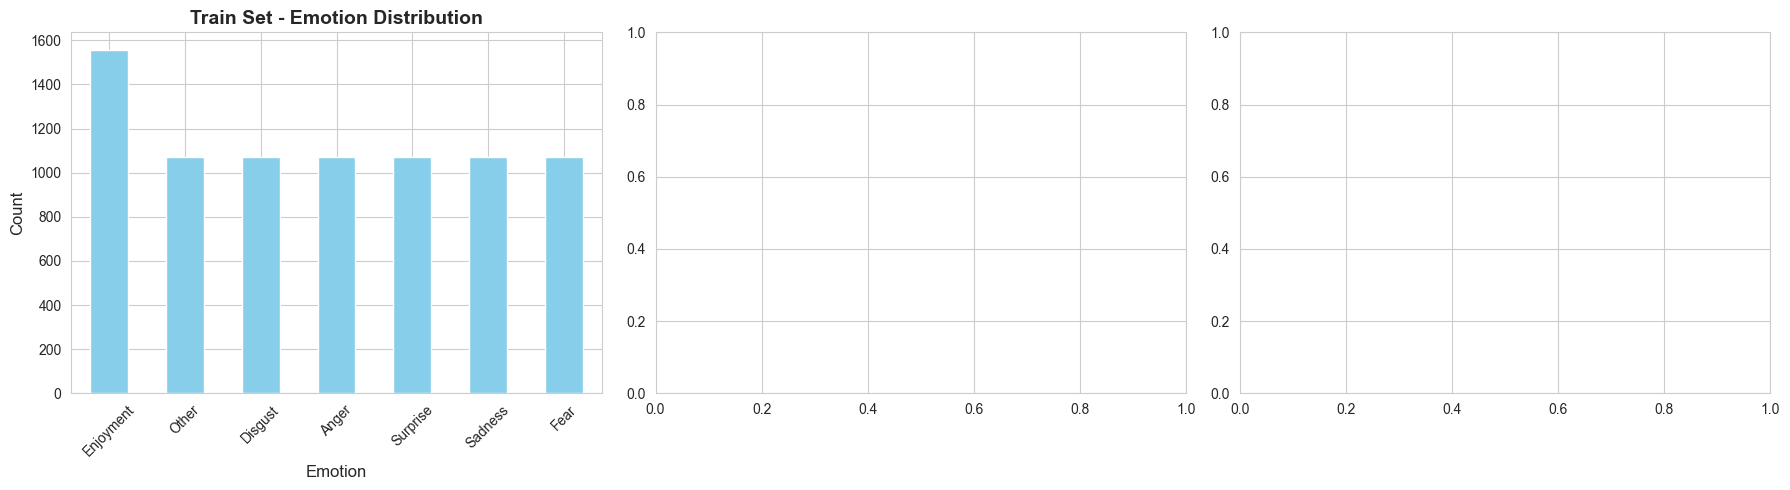

In [134]:
# Visualize emotion distribution across datasets
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Find emotion column
emotion_col = None
for col in train_df.columns:
    if 'emotion' in col.lower() or 'label' in col.lower():
        emotion_col = col
        break

if emotion_col:
    # Train set
    train_df[emotion_col].value_counts().plot(kind='bar', ax=axes[0], color='skyblue')
    axes[0].set_title('Train Set - Emotion Distribution', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Emotion', fontsize=12)
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].tick_params(axis='x', rotation=45)
    
    # # Validation set
    # val_df[emotion_col].value_counts().plot(kind='bar', ax=axes[1], color='lightcoral')
    # axes[1].set_title('Validation Set - Emotion Distribution', fontsize=14, fontweight='bold')
    # axes[1].set_xlabel('Emotion', fontsize=12)
    # axes[1].set_ylabel('Count', fontsize=12)
    # axes[1].tick_params(axis='x', rotation=45)
    
    # # Test set
    # test_df[emotion_col].value_counts().plot(kind='bar', ax=axes[2], color='lightgreen')
    # axes[2].set_title('Test Set - Emotion Distribution', fontsize=14, fontweight='bold')
    # axes[2].set_xlabel('Emotion', fontsize=12)
    # axes[2].set_ylabel('Count', fontsize=12)
    # axes[2].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
else:
    print("No emotion column found!")


In [135]:
# Check text statistics if there's a text column
text_cols = [col for col in train_df.columns if 'text' in col.lower() or 'content' in col.lower() or 'sentence' in col.lower()]
print("=" * 80)
print("TEXT STATISTICS:")
print("=" * 80)
print(f"\nPotential text columns: {text_cols}")

if text_cols:
    text_col = text_cols[0]
    
    # Calculate text lengths
    train_df['text_length'] = train_df[text_col].astype(str).apply(len)
    train_df['word_count'] = train_df[text_col].astype(str).apply(lambda x: len(x.split()))
    
    print(f"\nText Length Statistics:")
    print(train_df['text_length'].describe())
    print(f"\nWord Count Statistics:")
    print(train_df['word_count'].describe())


TEXT STATISTICS:

Potential text columns: ['Sentence']

Text Length Statistics:
count    7984.000000
mean       56.041082
std        38.479566
min         4.000000
25%        30.000000
50%        47.000000
75%        71.000000
max       640.000000
Name: text_length, dtype: float64

Word Count Statistics:
count    7984.000000
mean       13.884269
std         9.543357
min         1.000000
25%         8.000000
50%        12.000000
75%        17.000000
max       164.000000
Name: word_count, dtype: float64


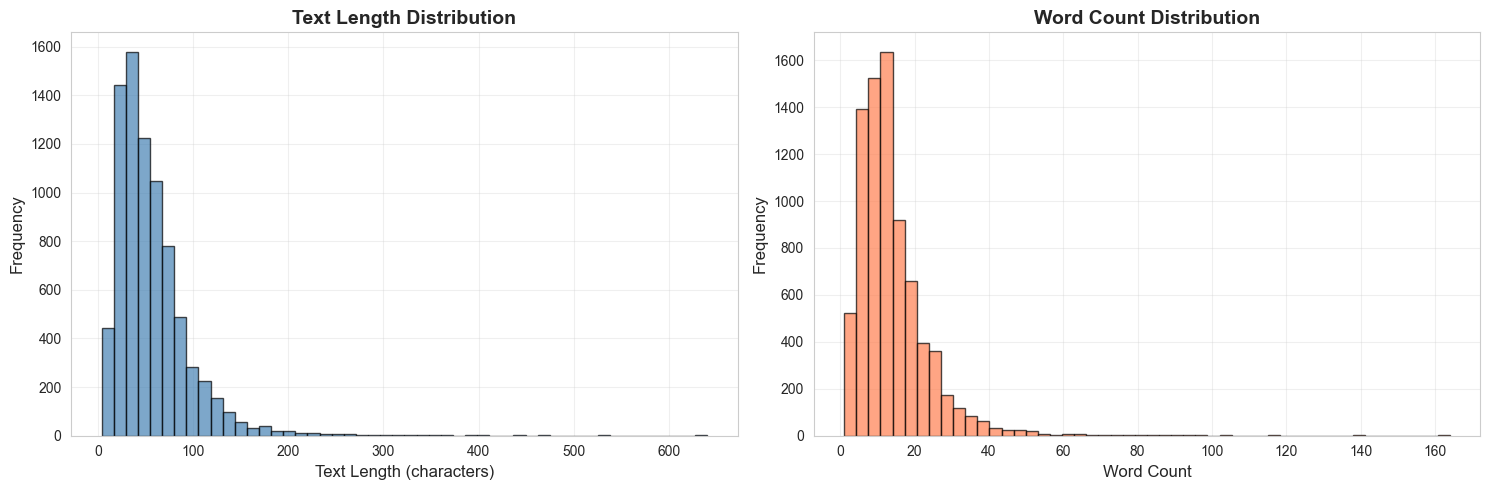

In [136]:
# Visualize text length distribution
if text_cols:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Text length distribution
    axes[0].hist(train_df['text_length'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0].set_title('Text Length Distribution', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Text Length (characters)', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    
    # Word count distribution
    axes[1].hist(train_df['word_count'], bins=50, color='coral', edgecolor='black', alpha=0.7)
    axes[1].set_title('Word Count Distribution', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Word Count', fontsize=12)
    axes[1].set_ylabel('Frequency', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


## Emotion Label Mapping
Now we'll map the English emotion labels to Vietnamese labels according to the specified mapping.


In [137]:
# Define emotion mapping
emotion_mapping = {
    "Anger": "giận dữ",
    "Disgust": "khó chịu",
    "Enjoyment": "vui vẻ",
    "Fear": "sợ hãi",
    "Other": "khác",
    "Sadness": "buồn",
    "Surprise": "ngạc nhiên"
}

print("=" * 80)
print("EMOTION MAPPING:")
print("=" * 80)
for eng, viet in emotion_mapping.items():
    print(f"{eng:15} -> {viet}")


EMOTION MAPPING:
Anger           -> giận dữ
Disgust         -> khó chịu
Enjoyment       -> vui vẻ
Fear            -> sợ hãi
Other           -> khác
Sadness         -> buồn
Surprise        -> ngạc nhiên


In [138]:
# Apply mapping to all datasets
if emotion_col:
    print(f"\nApplying mapping to column: {emotion_col}")
    print("\nBefore mapping - Unique values in train set:")
    print(train_df[emotion_col].unique())
    
    # Create new column with Vietnamese labels
    train_df['emotion_vn'] = train_df[emotion_col].map(emotion_mapping)
    # val_df['emotion_vn'] = val_df[emotion_col].map(emotion_mapping)
    # test_df['emotion_vn'] = test_df[emotion_col].map(emotion_mapping)
    
    print("\nAfter mapping - Unique values in train set:")
    print(train_df['emotion_vn'].unique())
    
    # Check for any unmapped values
    unmapped_train = train_df[train_df['emotion_vn'].isnull()][emotion_col].unique()
    # unmapped_val = val_df[val_df['emotion_vn'].isnull()][emotion_col].unique()
    # unmapped_test = test_df[test_df['emotion_vn'].isnull()][emotion_col].unique()
    
    if len(unmapped_train) > 0:
        print(f"\n⚠️ Warning: Unmapped values in train set: {unmapped_train}")
    # if len(unmapped_val) > 0:
    #     print(f"⚠️ Warning: Unmapped values in validation set: {unmapped_val}")
    # if len(unmapped_test) > 0:
    #     print(f"⚠️ Warning: Unmapped values in test set: {unmapped_test}")
    
    # if len(unmapped_train) == 0 and len(unmapped_val) == 0 and len(unmapped_test) == 0:
    #     print("\n✓ All emotion labels successfully mapped!")
    
    # Keep only Sentence_clean and emotion_vn columns, drop original Sentence column
    train_df = train_df[['Emotion', 'Sentence', 'emotion_vn']]
    
    # val_df = val_df[['Sentence_clean', 'emotion_vn']]
    # test_df = test_df[['Sentence_clean', 'emotion_vn']]
    
    print("\n✓ Columns renamed and filtered to ['Sentence_clean', 'emotion_vn']")
    print(f"Train columns: {train_df.columns.tolist()}")
else:
    print("No emotion column found for mapping!")



Applying mapping to column: Emotion

Before mapping - Unique values in train set:
['Other' 'Disgust' 'Enjoyment' 'Anger' 'Surprise' 'Sadness' 'Fear']

After mapping - Unique values in train set:
['khác' 'khó chịu' 'vui vẻ' 'giận dữ' 'ngạc nhiên' 'buồn' 'sợ hãi']

✓ Columns renamed and filtered to ['Sentence_clean', 'emotion_vn']
Train columns: ['Emotion', 'Sentence', 'emotion_vn']


In [139]:
# Display distribution of Vietnamese emotion labels
if emotion_col:
    print("=" * 80)
    print("VIETNAMESE EMOTION LABELS DISTRIBUTION:")
    print("=" * 80)
    
    print("\nTrain set:")
    print(train_df['emotion_vn'].value_counts())
    
    # print("\nValidation set:")
    # print(val_df['emotion_vn'].value_counts())
    
    # print("\nTest set:")
    # print(test_df['emotion_vn'].value_counts())


VIETNAMESE EMOTION LABELS DISTRIBUTION:

Train set:
emotion_vn
vui vẻ        1558
khác          1071
khó chịu      1071
giận dữ       1071
ngạc nhiên    1071
buồn          1071
sợ hãi        1071
Name: count, dtype: int64


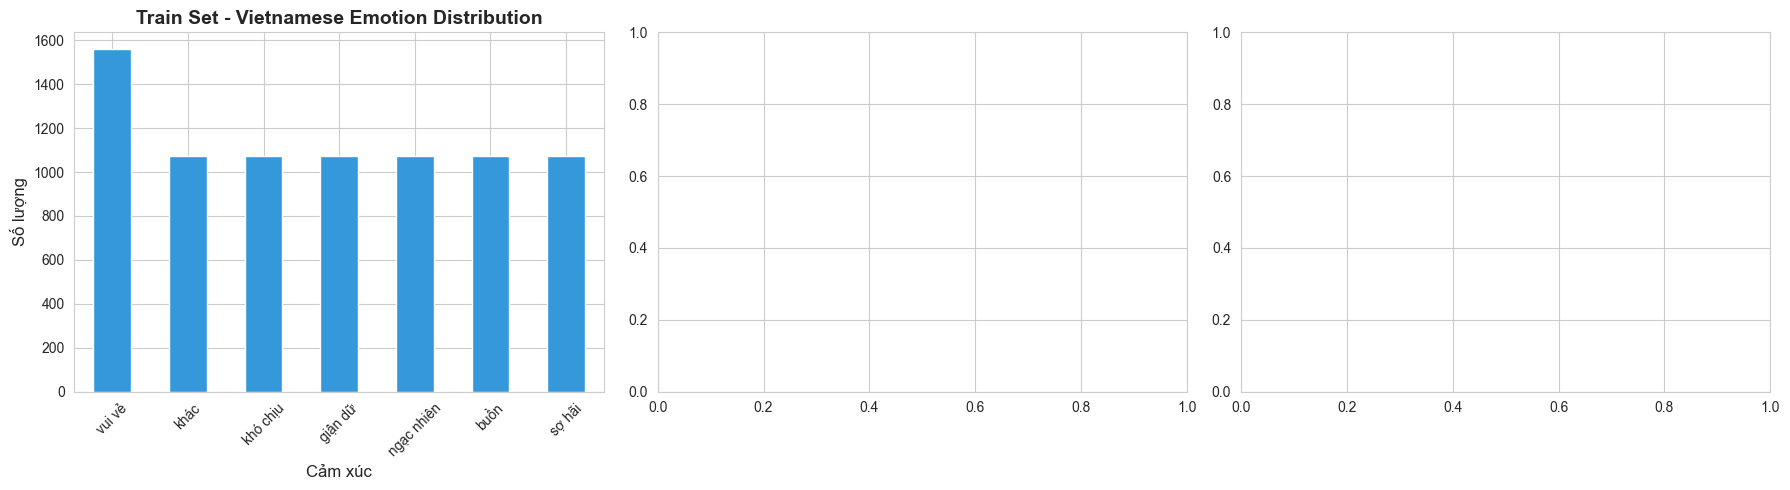

In [140]:
# Visualize Vietnamese emotion distribution
if emotion_col:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Train set
    train_df['emotion_vn'].value_counts().plot(kind='bar', ax=axes[0], color='#3498db')
    axes[0].set_title('Train Set - Vietnamese Emotion Distribution', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Cảm xúc', fontsize=12)
    axes[0].set_ylabel('Số lượng', fontsize=12)
    axes[0].tick_params(axis='x', rotation=45)
    
    # # Validation set
    # val_df['emotion_vn'].value_counts().plot(kind='bar', ax=axes[1], color='#e74c3c')
    # axes[1].set_title('Validation Set - Vietnamese Emotion Distribution', fontsize=14, fontweight='bold')
    # axes[1].set_xlabel('Cảm xúc', fontsize=12)
    # axes[1].set_ylabel('Số lượng', fontsize=12)
    # axes[1].tick_params(axis='x', rotation=45)
    
    # # Test set
    # test_df['emotion_vn'].value_counts().plot(kind='bar', ax=axes[2], color='#2ecc71')
    # axes[2].set_title('Test Set - Vietnamese Emotion Distribution', fontsize=14, fontweight='bold')
    # axes[2].set_xlabel('Cảm xúc', fontsize=12)
    # axes[2].set_ylabel('Số lượng', fontsize=12)
    # axes[2].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()


In [141]:
# Display sample data with both English and Vietnamese labels
if emotion_col:
    print("=" * 80)
    print("SAMPLE DATA WITH EMOTION LABELS:")
    print("=" * 80)
    
    # Show relevant columns
    display_cols = [col for col in train_df.columns if col not in ['text_length', 'word_count']]
    print("\nFirst 10 samples from train set:")
    train_df[display_cols].head(10)


SAMPLE DATA WITH EMOTION LABELS:

First 10 samples from train set:


In [142]:
# Keep only the required columns and drop others
print("=" * 80)
print("COLUMN FILTERING:")
print("=" * 80)

print(f"\nOriginal columns: {list(train_df.columns)}")

# Keep only the specified columns
required_cols = ['Sentence', 'Emotion', 'emotion_vn']
train_df = train_df[required_cols]

print(f"Filtered columns: {list(train_df.columns)}")
print(f"Train dataset shape after filtering: {train_df.shape}")

print("\n✓ Column filtering completed successfully!")


COLUMN FILTERING:

Original columns: ['Emotion', 'Sentence', 'emotion_vn']
Filtered columns: ['Sentence', 'Emotion', 'emotion_vn']
Train dataset shape after filtering: (7984, 3)

✓ Column filtering completed successfully!


## Summary Statistics


In [143]:
# Create comprehensive summary
print("=" * 80)
print("COMPREHENSIVE DATA SUMMARY:")
print("=" * 80)

print("\n1. Dataset Sizes:")
print(f"   - Train: {len(train_df):,} samples")
# print(f"   - Validation: {len(val_df):,} samples")
# print(f"   - Test: {len(test_df):,} samples")
# print(f"   - Total: {len(train_df) + len(val_df) + len(test_df):,} samples")

if emotion_col:
    print("\n2. Emotion Class Balance (Train Set):")
    class_counts = train_df['emotion_vn'].value_counts()
    for emotion, count in class_counts.items():
        percentage = (count / len(train_df)) * 100
        print(f"   - {emotion}: {count:,} ({percentage:.2f}%)")
    
    print("\n3. Class Distribution Summary:")
    print(f"   - Number of classes: {train_df['emotion_vn'].nunique()}")
    print(f"   - Most common: {class_counts.index[0]} ({class_counts.iloc[0]:,} samples)")
    print(f"   - Least common: {class_counts.index[-1]} ({class_counts.iloc[-1]:,} samples)")
    print(f"   - Imbalance ratio: {class_counts.iloc[0] / class_counts.iloc[-1]:.2f}x")


print("\n✓ EDA and emotion mapping completed successfully!")


COMPREHENSIVE DATA SUMMARY:

1. Dataset Sizes:
   - Train: 7,984 samples

2. Emotion Class Balance (Train Set):
   - vui vẻ: 1,558 (19.51%)
   - khác: 1,071 (13.41%)
   - khó chịu: 1,071 (13.41%)
   - giận dữ: 1,071 (13.41%)
   - ngạc nhiên: 1,071 (13.41%)
   - buồn: 1,071 (13.41%)
   - sợ hãi: 1,071 (13.41%)

3. Class Distribution Summary:
   - Number of classes: 7
   - Most common: vui vẻ (1,558 samples)
   - Least common: sợ hãi (1,071 samples)
   - Imbalance ratio: 1.45x

✓ EDA and emotion mapping completed successfully!


In [144]:
# Display all columns and top 5 rows for each dataset
print("=" * 80)
print("DATASET PREVIEW - ALL COLUMNS:")
print("=" * 80)

print("\n" + "="*50)
print("TRAIN DATASET (Top 5 rows):")
print("="*50)
print(f"Shape: {train_df.shape}")
print(f"Columns: {list(train_df.columns)}")
print("\nData:")
display(train_df.head())

# print("\n" + "="*50)
# print("VALIDATION DATASET (Top 5 rows):")
# print("="*50)
# print(f"Shape: {val_df.shape}")
# print(f"Columns: {list(val_df.columns)}")
# print("\nData:")
# display(val_df.head())

# print("\n" + "="*50)
# print("TEST DATASET (Top 5 rows):")
# print("="*50)
# print(f"Shape: {test_df.shape}")
# print(f"Columns: {list(test_df.columns)}")
# print("\nData:")
# display(test_df.head())


DATASET PREVIEW - ALL COLUMNS:

TRAIN DATASET (Top 5 rows):
Shape: (7984, 3)
Columns: ['Sentence', 'Emotion', 'emotion_vn']

Data:


,Sentence,Emotion,emotion_vn
0,cho mình xin bài nhạc tên là gì với ạ,Other,khác
1,cho đáng đời con quỷ . về nhà lôi con nhà mày ...,Disgust,khó chịu
2,lo học đi . yêu đương lol gì hay lại thích học...,Disgust,khó chịu
3,uớc gì sau này về già vẫn có thể như cụ này :)),Enjoyment,vui vẻ
4,mỗi lần có video của con là cứ coi đi coi lại ...,Enjoyment,vui vẻ


In [145]:
# Save processed datasets to CSV files
print("=" * 80)
print("SAVING PROCESSED DATASETS:")
print("=" * 80)

# Define output paths
train_path = 'data/processed/train_1071_para_processed.csv'
# val_path = 'data/processed/val_processed.csv'
# test_path = 'data/processed/test_processed.csv'
# train_path = 'data/processed/augmented_1500_processed.csv'

# Create output directory if it doesn't exist
import os
os.makedirs('data/processed', exist_ok=True)

# Save datasets
print(f"\nSaving train set to: {train_path}")
train_df.to_csv(train_path, index=False, encoding='utf-8')
print(f"✓ Train set saved: {len(train_df):,} samples")

# print(f"\nSaving validation set to: {val_path}")
# val_df.to_csv(val_path, index=False, encoding='utf-8')
# print(f"✓ Validation set saved: {len(val_df):,} samples")

# print(f"\nSaving test set to: {test_path}")
# test_df.to_csv(test_path, index=False, encoding='utf-8')
# print(f"✓ Test set saved: {len(test_df):,} samples")

print(f"\n✓ All datasets saved successfully to 'data/processed/' directory!")


SAVING PROCESSED DATASETS:

Saving train set to: data/processed/train_1071_para_processed.csv
✓ Train set saved: 7,984 samples

✓ All datasets saved successfully to 'data/processed/' directory!
